In [1]:
from functools import partial
import json
from pathlib import Path
import sys
from typing import cast

# Add repo root to Python path (notebook is at scripts/smc/smc.ipynb)
sys.path.insert(0, str(Path().resolve().parents[1]))

from model_smc import init_sample, propagate_sample, log_potential
import cuthbert
from cuthbert.smc.particle_filter import build_filter, partial
from cuthbertlib.resampling import adaptive, systematic

from cuthberto_carlos.data import download_data

import jax.numpy as jnp
import jax

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

N = 10  # Reduced from 1000 to avoid memory issues
MAX_GOALS = 8

# Offline Filtering

In [ ]:
pd_data, jax_data, teams_id_to_name_dict, _ = download_data(max_goals=MAX_GOALS)
num_teams = len(teams_id_to_name_dict)

pd_data

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,timestamp_days,friendly,home_team_id,away_team_id,home_timestamp_previous,away_timestamp_previous
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,0,True,253,91,0,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,98,True,91,253,0,0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,462,True,253,91,98,98
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,826,True,91,253,462,462
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1190,True,253,91,826,826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49436,2026-06-19,Turkey,Paraguay,0,1,FIFA World Cup,Santa Clara,United States,True,56083,False,298,221,56077,56076
49437,2026-06-20,Germany,Ivory Coast,2,1,FIFA World Cup,Toronto,Canada,True,56084,False,111,143,56078,56078
49438,2026-06-20,Ecuador,Curaçao,0,0,FIFA World Cup,Kansas City,United States,True,56084,False,86,73,56078,56078
49439,2026-06-20,Netherlands,Sweden,5,1,FIFA World Cup,Houston,United States,True,56084,False,198,279,56078,56078


In [ ]:


# resampling function
resampling_fn = adaptive.ess_decorator(
    func=systematic.resampling, 
    threshold=0.5,
)
# build filter
# pass number of teams to init_sample function using partial
smc_filter = build_filter(
    init_sample=partial(
        init_sample,
        num_teams=num_teams,
    ),
    propagate_sample=propagate_sample,
    log_potential=log_potential,
    n_filter_particles = N,
    resampling_fn=resampling_fn,
    
)
# offline filtering
key, previous_key = jax.random.split(jax.random.PRNGKey(0))
previous_states = cuthbert.filter(
    filter_obj=smc_filter,
    model_inputs=jax_data,
    key=key,
    )
filter_state = jax.tree.map(lambda x: x[-1], previous_states)

In [4]:
# (N, num_teams, 2)
filter_state.particles.shape

(10, 333, 2)

In [3]:

# Get mean attack and defense across particles for each team
# filter_state.particles has shape (N, num_teams, 2)
particles_np = np.array(filter_state.particles)  # Convert from JAX to numpy
attack_mean = particles_np[:, :, 0].mean(axis=0)   # (num_teams,)
defense_mean = particles_np[:, :, 1].mean(axis=0)  # (num_teams,)

# Create DataFrame
latest_rank = pd.DataFrame({
    'country': [teams_id_to_name_dict[i] for i in range(num_teams)],
    'attack': attack_mean,
    'defense': defense_mean
})

print("Top 10 Countries by Attack:")
for c in latest_rank.sort_values(by='attack', ascending=False).head(10).values:
    print(f"Country: {c[0]}, Attack: {c[1]:.4f}, Defense: {c[2]:.4f}")

print("Top 10 Countries by Defense:")
for c in latest_rank.sort_values(by='defense', ascending=False).head(10).values:
    print(f"Country: {c[0]}, Attack: {c[1]:.4f}, Defense: {c[2]:.4f}")

Top 10 Countries by Attack:
Country: American Samoa, Attack: 0.3179, Defense: -0.0387
Country: Northern Ireland, Attack: 0.2510, Defense: -0.0786
Country: Somalia, Attack: 0.1888, Defense: 0.2110
Country: Turkmenistan, Attack: 0.1871, Defense: 0.2819
Country: North Macedonia, Attack: 0.1834, Defense: -0.0641
Country: Matabeleland, Attack: 0.1833, Defense: 0.1054
Country: Felvidék, Attack: 0.1823, Defense: 0.0222
Country: Belize, Attack: 0.1777, Defense: 0.0982
Country: Nepal, Attack: 0.1757, Defense: 0.0546
Country: Elba Island, Attack: 0.1712, Defense: 0.0107
Top 10 Countries by Defense:
Country: Turkmenistan, Attack: 0.1871, Defense: 0.2819
Country: Hong Kong, Attack: 0.0514, Defense: 0.2333
Country: Gabon, Attack: -0.0602, Defense: 0.2324
Country: Jersey, Attack: 0.0080, Defense: 0.2216
Country: Somalia, Attack: 0.1888, Defense: 0.2110
Country: Falkland Islands, Attack: -0.0589, Defense: 0.2079
Country: French Guiana, Attack: -0.0248, Defense: 0.1968
Country: San Marino, Attack: -0.

Matches where France played:
      match_index       date home_team         away_team    attack   defense  \
5719        48632 2026-03-26    Brazil            France  0.048948  0.000966   
5789        48702 2026-03-29  Colombia            France  0.047729  0.002141   
5906        48819 2026-06-04    France       Ivory Coast -0.085390 -0.007165   
5971        48884 2026-06-08    France  Northern Ireland -0.067478 -0.012842   
6017        48930 2026-06-16    France           Senegal -0.014049 -0.019076   

      france_played  
5719           True  
5789           True  
5906           True  
5971           True  
6017           True  


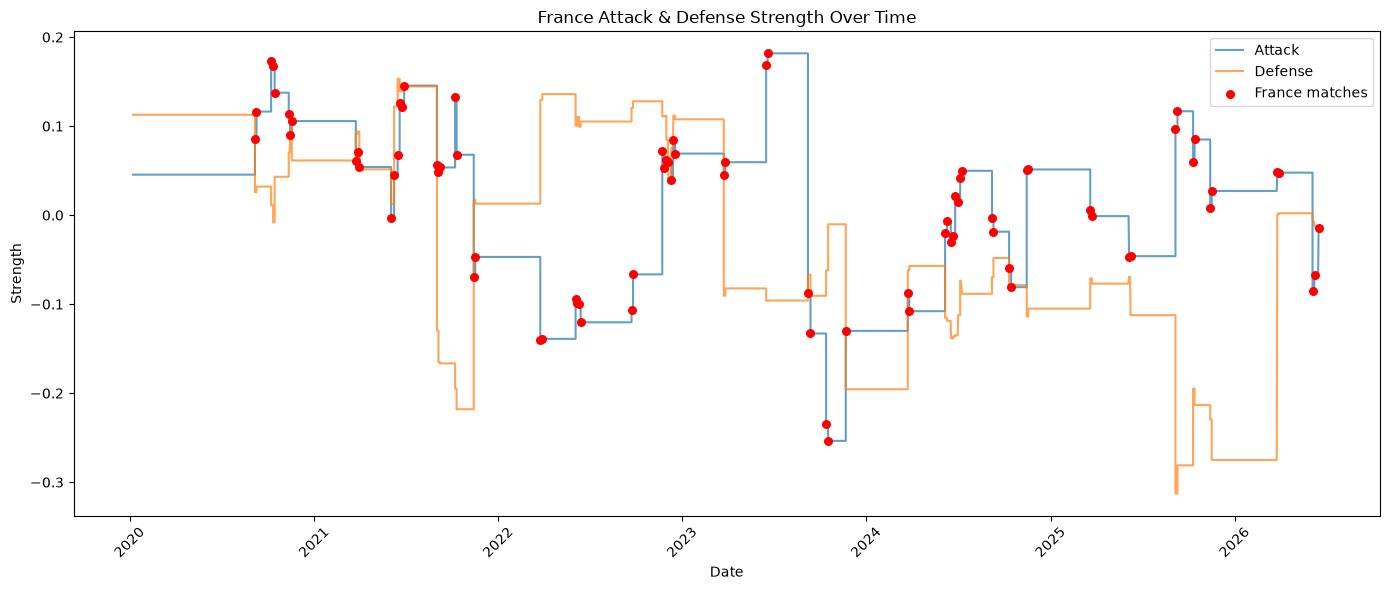

In [4]:
# Get team ID for France
france_id = 102  # or teams_name_to_id_dict['France']

# Extract France's particles over all matches
# previous_states.particles has shape (num_matches, N, num_teams, 2)
france_over_time = previous_states.particles[:, :, france_id, :]  # (num_matches, N, 2)

# Get mean attack/defence at each timestep
france_attack_mean = france_over_time[:, :, 0].mean(axis=1)  # (num_matches,)
france_defence_mean = france_over_time[:, :, 1].mean(axis=1)  # (num_matches,)

# Create a DataFrame with France's attack/defense over time with dates
france_df = pd.DataFrame({
    'match_index': range(len(france_attack_mean)),
    'date': pd_data['date'].values[:len(france_attack_mean)],
    'home_team': pd_data['home_team'].values[:len(france_attack_mean)],
    'away_team': pd_data['away_team'].values[:len(france_attack_mean)],
    'attack': np.array(france_attack_mean),
    'defense': np.array(france_defence_mean),
})

# Add a column indicating if France was playing in this match
france_name = 'France'
france_df['france_played'] = (
    (france_df['home_team'] == france_name) | 
    (france_df['away_team'] == france_name)
)
france_df = france_df[france_df['date'] >= pd.Timestamp('2020-01-01')].reset_index(drop=True)

# Show matches where France played
print("Matches where France played:")
print(france_df[france_df['france_played']].tail(5))

# Plot with dates on x-axis
plt.figure(figsize=(14, 6))
plt.plot(france_df['date'], france_df['attack'], label='Attack', alpha=0.7)
plt.plot(france_df['date'], france_df['defense'], label='Defense', alpha=0.7)

# Highlight matches where France played
france_matches = france_df[france_df['france_played']]
plt.scatter(france_matches['date'], france_matches['attack'], 
           color='red', s=30, label='France matches', zorder=5)

plt.title('France Attack & Defense Strength Over Time')
plt.xlabel('Date')
plt.ylabel('Strength')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Comparing Distributions